# Moving to Nonlinear Models

Last semester, you primarily worked with linear models, where the question of "what can we do with linear combinations of our features" is the core idea.  Of course, if the vector space defined by your features isn’t useful, the answer is, “not very much.” This can seem extremely limiting. For example, consider the following regression problem, where we'd like to fit these points:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import argparse
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import plotly.graph_objects as go
import sklearn.linear_model

In [2]:
'''
Generate N 2d datapoints, around a random parabola, plus noise
'''
def genData(N,noise=1):
    line=np.random.randn(3) #random A,B,C for Ax^2+Bx+C=0
    xs=np.random.random(N)*20-10 #random points on x-axis between -10 and 10

    #for each of those points, calculate x^2,x,and 1, and add in some random
    #error
    data=np.asarray( [[x*x,x,1+noise*np.random.randn()] for x in xs] )
    ys=data@line #calculate resulting y value
    return xs,ys

'''
Calculate the line of best fit in original x,y space. This will be bad!
'''
def plotItLin(xs,ys):
    plt.plot(xs,ys,'.')
    data=np.ones((N,2))
    data[:,0]=xs
    w=linReg(data,ys)
    plt.plot([-10,10],np.array([[-10,1],[10, 1]])@w)
    plt.show()

'''
Fancy-shmancy drawing of points and plane of best fit in x,x^2 space
'''
def plot3D(xs,ys,data,w=None):
  fig=plt.figure()
  ax=Axes3D(fig)
  if w is not None:
    X=np.arange(-10,10)
    XSq=np.arange(0,100)
    plane=np.asarray([[xsq,x,1] for xsq in XSq for x in X])@w
    plane=plane.reshape((100,20))
    X,XSq=np.meshgrid(X,XSq)
    ax.plot_surface(X,XSq,plane,color="lightgray",shade=False,\
        alpha=.7)
  ax.scatter(data[:,1],data[:,0],ys)
  ax.set_xlabel('$x$')
  ax.set_ylabel('$x^2$')
  ax.set_zlabel('$y$')
  plt.show()

'''
Draw all the stuff to explain regression in 3d space
'''
def plotItQuad(xs,ys):
  data=np.asarray( [[x*x, x, 1] for x in xs] )
  plot3D(xs,ys,data) #plot points in 3d space
  w=linReg(data,ys) #calculate the plane of best fit
  plot3D(xs,ys,data,w) #plot points and plane in 3d space

  #plot resulting parabola in original 2d space
  plt.plot(xs,ys,'.')
  allXs=np.linspace(-10,10)
  allXData=np.asarray([[x*x,x,1] for x in allXs])
  allYs=allXData@w
  plt.plot(allXs,allYs)
  plt.show()

'''
Let's add more monomial features! x^3, x^4, up to x^9
'''
def overFitIt(xs,ys):
  data=np.asarray( [[pow(x,i) for i in range(11)] for x in xs] )
  fig,axes=plt.subplots(3,3,sharex='col')
  curr=1
  allXs=np.linspace(-10,10)
  allXdata=np.asarray( [[pow(x,i) for i in range(11)] for x in allXs] )
  for row in range(3):
    for col in range(3):
      axes[row,col].plot(xs,ys,'.')
      w=linReg(data[:,:curr+1],ys)
      axes[row,col].plot(allXs,allXdata[:,:curr+1]@w)
      
      ypreds=data[:,:curr+1]@w
      err=(1/len(xs))*np.linalg.norm(ypreds-ys)
      axes[row,col].set_title("$E_{in}=%.4f$"%err)

      axes[row,col].set_yticklabels([])

      curr=curr+1
  plt.show()

def plotPoints(xs,ys):
    fig=px.scatter(x=xs,y=ys)
    fig.update_layout(width=700,height=500)
    fig.show()


In [3]:
N=25
noise=8

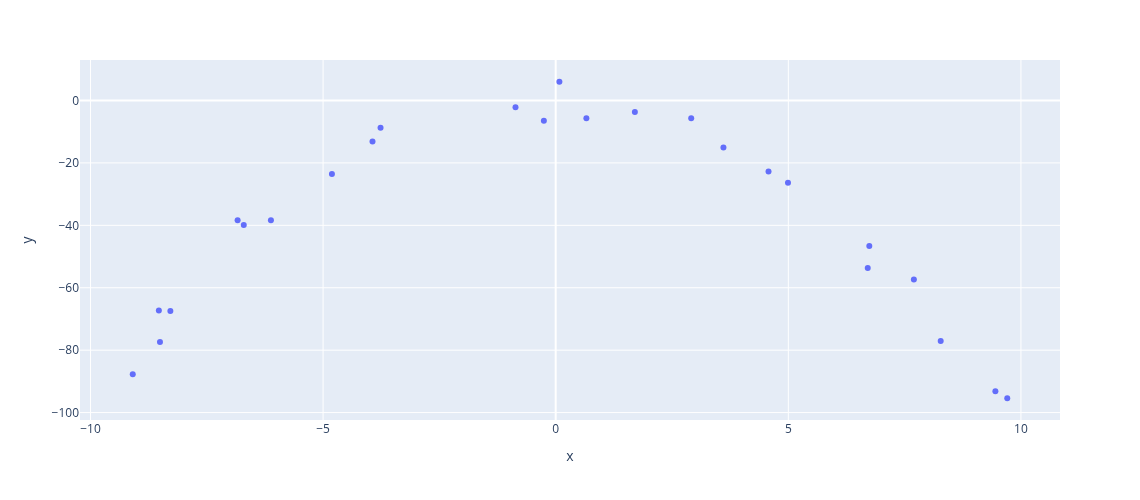

In [4]:
xs,ys=genData(N,noise=noise)
fig=px.scatter(x=xs,y=ys)
fig.update_layout(width=700,height=500)
fig.show()

Now, this is not easy to do with a line. But we can try! We use Ridge Regression, and draw the resulting predictions.

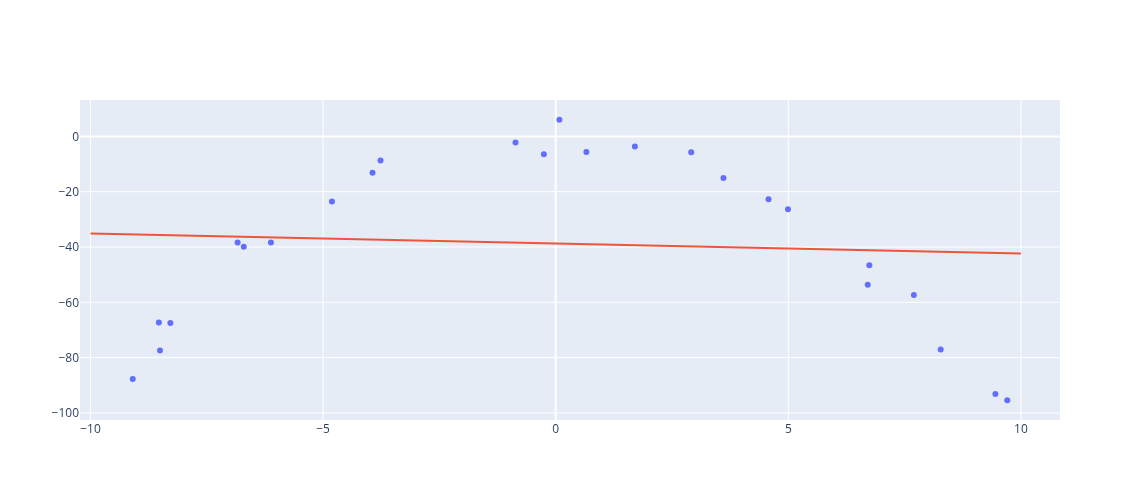

In [5]:
lr=sklearn.linear_model.Ridge(alpha=.0001)
lr.fit(xs.reshape(-1,1),ys)
linexs=np.linspace(-10,10)
lineys=linexs*lr.coef_[0]+lr.intercept_
scatter=go.Scatter(x=xs,y=ys,mode='markers',showlegend=False)
line=go.Scatter(x=linexs,y=lineys,mode='lines',showlegend=False)
fig=go.Figure(data=[scatter,line])
fig.update_layout(width=700,height=500)
fig.show()

Yeah, not good.

But, we can add a feature. We can think of these points as being represented by the vector $[x_i, 1]$ with associated label $y_i$. We can create matrices of all our datapoints and labels as:

$$
X = \begin{bmatrix} x_1 & 1 \\ x_2 & 1 \\ x_3 & 1 \\ \vdots & \vdots \end{bmatrix}, ~~~ y = \begin{bmatrix} y_1 \\ y_2 \\ y_3 \\ \vdots \end{bmatrix},
$$

and define linear regression as our optimization problem

$$
\min_w \left|| Xw-y \right||_2.
$$

Now, we're going to do "polynomial regression" as it's called in your book from last year, and create an additional feature $x_2$. So, a point $[x_i~1]=[5~1]$ will now be represented as $[x_i^2~x_i~1]=[25~5~1]$. The points below represent the same ones above, but in this new space, where two of the dimensions are $x$ and $x^2$.  Looks like maybe we could fit a plane to it!

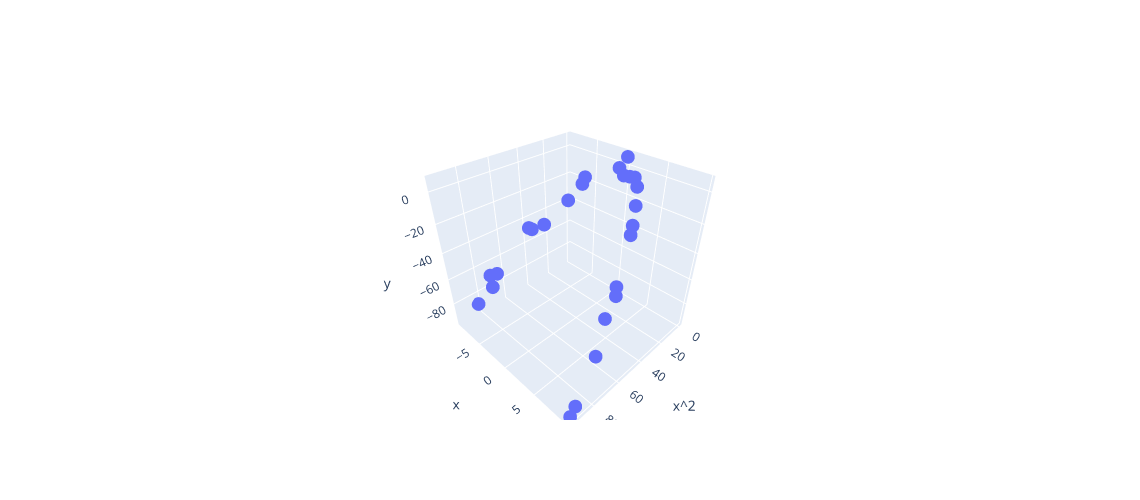

In [6]:
Phi=np.zeros((25,2))
Phi[:,0]=xs*xs
Phi[:,1]=xs

scat=go.Scatter3d(x=Phi[:,0],y=Phi[:,1],z=ys,mode='markers')
fig=go.Figure(data=scat)
fig.update_layout(scene=dict(xaxis_title='x^2',yaxis_title='x',zaxis_title='y'))
fig.update_layout(width=700,height=500)
fig.show()

We use Ridge regression to fit this data. Again, linear regression can only fit flat things - but here, it's not a line, it's a plane. And a plane fits beautifully.

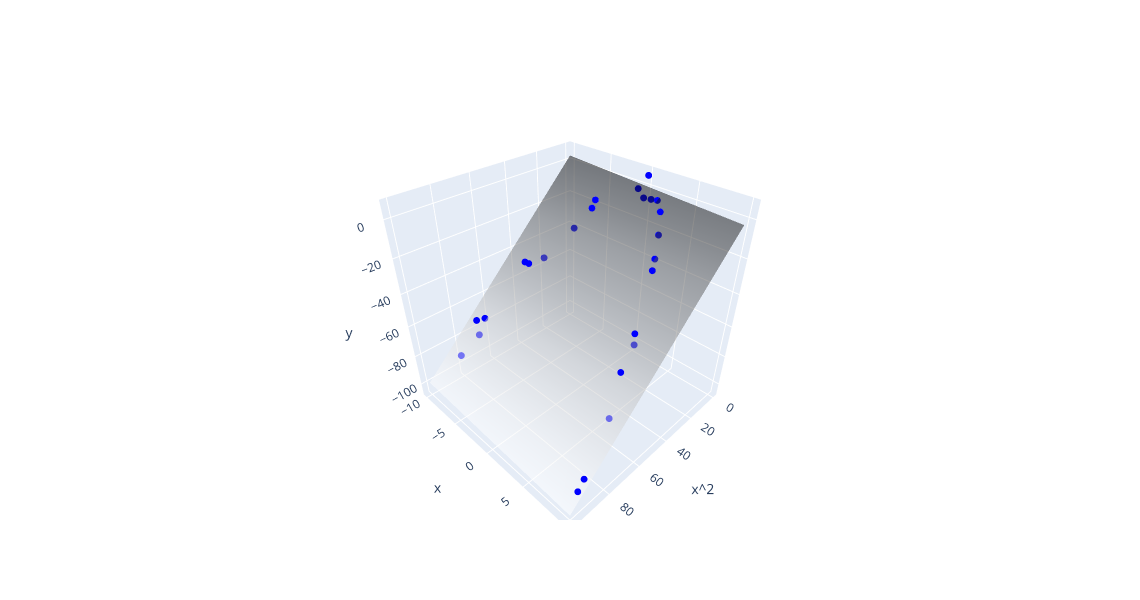

In [8]:
import numpy as np
import plotly.graph_objects as go

# 1. Fit the model (using existing Phi and ys)
lr = sklearn.linear_model.Ridge(alpha=.0001)
lr.fit(Phi, ys)

# 2. Create the scatter points
scat = go.Scatter3d(x=Phi[:, 0], y=Phi[:, 1], z=ys, mode='markers', marker=dict(size=4, color='blue'))

# 3. Create a 2D grid for the surface plane
x_range = np.linspace(0, 100, 20)  # Range for x^2
y_range = np.linspace(-10, 10, 20) # Range for x
x_grid, y_grid = np.meshgrid(x_range, y_range)

# 4. Calculate Z (y predict) across the grid
# z = w1*(x^2) + w2*(x) + intercept
z_grid = lr.coef_[0] * x_grid + lr.coef_[1] * y_grid + lr.intercept_

# 5. Define the surface
plane = go.Surface(x=x_grid, y=y_grid, z=z_grid, colorscale='Greys', opacity=0.5, showscale=False)

# 6. Plot both
fig = go.Figure(data=[scat, plane])
fig.update_layout(
    scene=dict(
        xaxis_title='x^2',
        yaxis_title='x',
        zaxis_title='y'
    ),
    width=800,
    height=600
)
fig.show()

This solution is just a weight times $x^2$, a weight times $x$, and a weight times $1$ - which is to say, a parabola. We can draw that parabola in the original space. And it fits great.

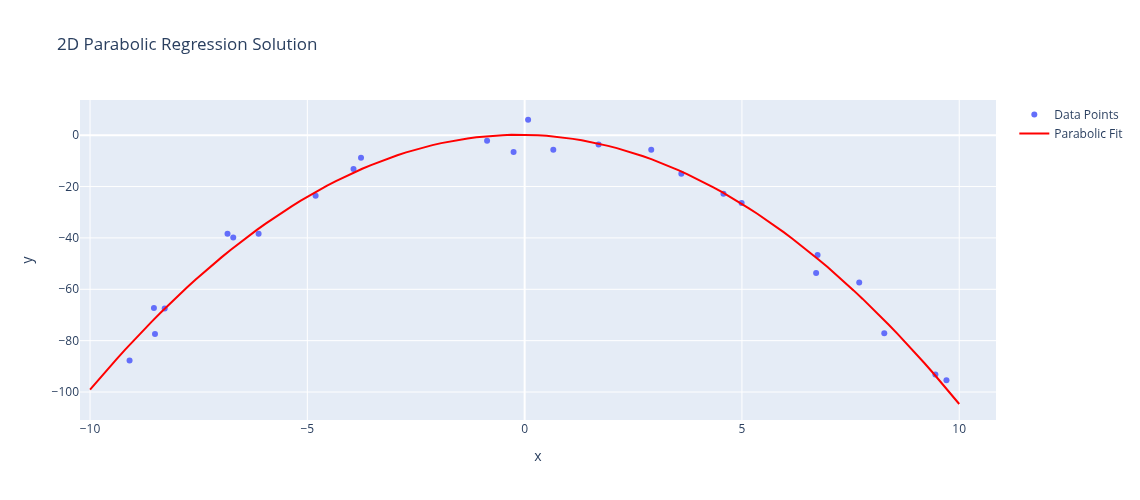

In [9]:
import numpy as np
import plotly.graph_objects as go

# 1. Create a dense range of x values for a smooth curve
x_curve = np.linspace(-10, 10, 100)

# 2. Calculate the corresponding y values using the model coefficients
# y = (coef for x^2) * x^2 + (coef for x) * x + intercept
y_curve = lr.coef_[0] * (x_curve**2) + lr.coef_[1] * x_curve + lr.intercept_

# 3. Create the scatter points of the original data
scat_2d = go.Scatter(x=xs, y=ys, mode='markers', name='Data Points')

# 4. Create the line plot for the parabolic solution
line_2d = go.Scatter(x=x_curve, y=y_curve, mode='lines', name='Parabolic Fit', line=dict(color='red'))

# 5. Plot both
fig_2d = go.Figure(data=[scat_2d, line_2d])
fig_2d.update_layout(
    xaxis_title='x',
    yaxis_title='y',
    width=800,
    height=500,
    title='2D Parabolic Regression Solution'
)
fig_2d.show()

So, that additional feature allowed us to do a *linear* fit, using *nonlinear* features, creating a *nonlinear* prediction.

## Nonlinear features for Classification

We do the same thing with Classification. Here are some points we'd like to classify using Logistic Regression (which just draws a linear decision boundary).

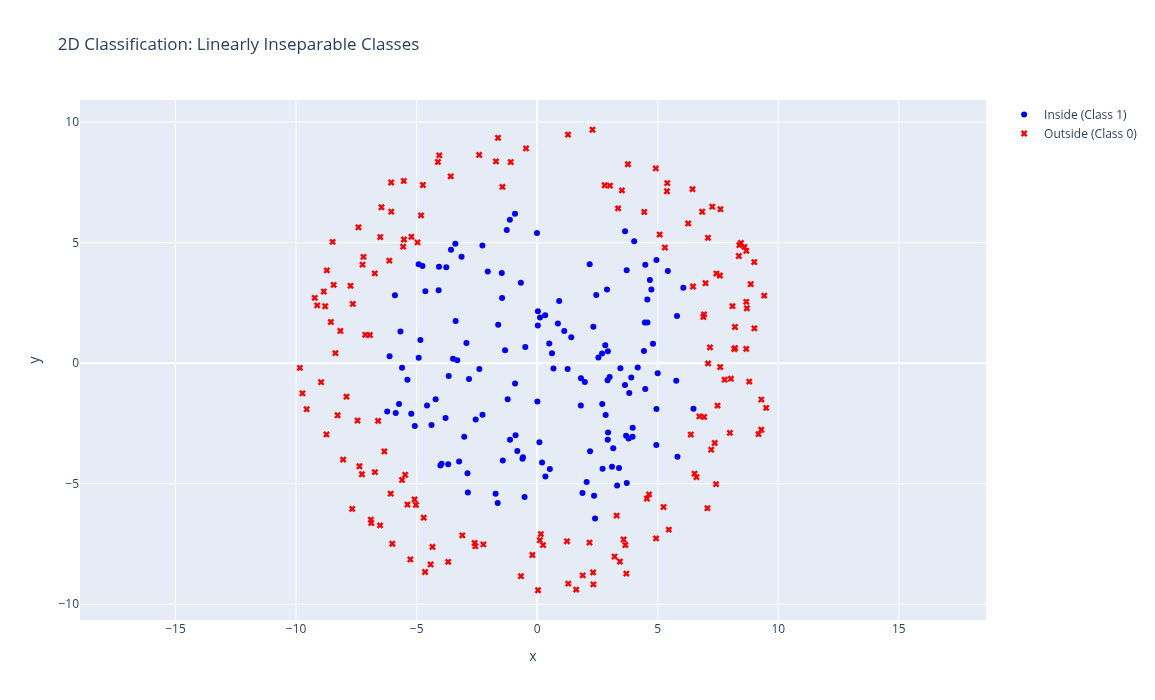

In [10]:
import numpy as np
import plotly.graph_objects as go

# 1. Generate random points
N_points = 300
np.random.seed(42)
r = 10 * np.sqrt(np.random.rand(N_points)) # Radius
theta = 2 * np.pi * np.random.rand(N_points) # Angle

x_class = r * np.cos(theta)
y_class = r * np.sin(theta)

# 2. Assign labels based on a circular boundary (Radius = 7)
# Label 1 for points inside the circle (r < 7), Label 0 for outside
labels = (r < 7).astype(int)

# 3. Separate points for plotting
class_1 = labels == 1
class_0 = labels == 0

# 4. Plot in 2D space (x vs y)
fig_class = go.Figure()

# Add "Inside" points
fig_class.add_trace(go.Scatter(
    x=x_class[class_1], y=y_class[class_1],
    mode='markers', name='Inside (Class 1)',
    marker=dict(color='blue', symbol='circle')
))

# Add "Outside" points
fig_class.add_trace(go.Scatter(
    x=x_class[class_0], y=y_class[class_0],
    mode='markers', name='Outside (Class 0)',
    marker=dict(color='red', symbol='x')
))

fig_class.update_layout(
    xaxis_title='x',
    yaxis_title='y',
    width=700,
    height=700,
    title='2D Classification: Linearly Inseparable Classes',
    xaxis=dict(scaleanchor="y", scaleratio=1) # Ensure circle looks like a circle
)

fig_class.show()

It won't work! So, we create some new features, namely, $x^2$ and $y^2$. Say we had a point $[3,~2]$. In our new space, it would be in $[9,~4]$. Here's what that looks like:

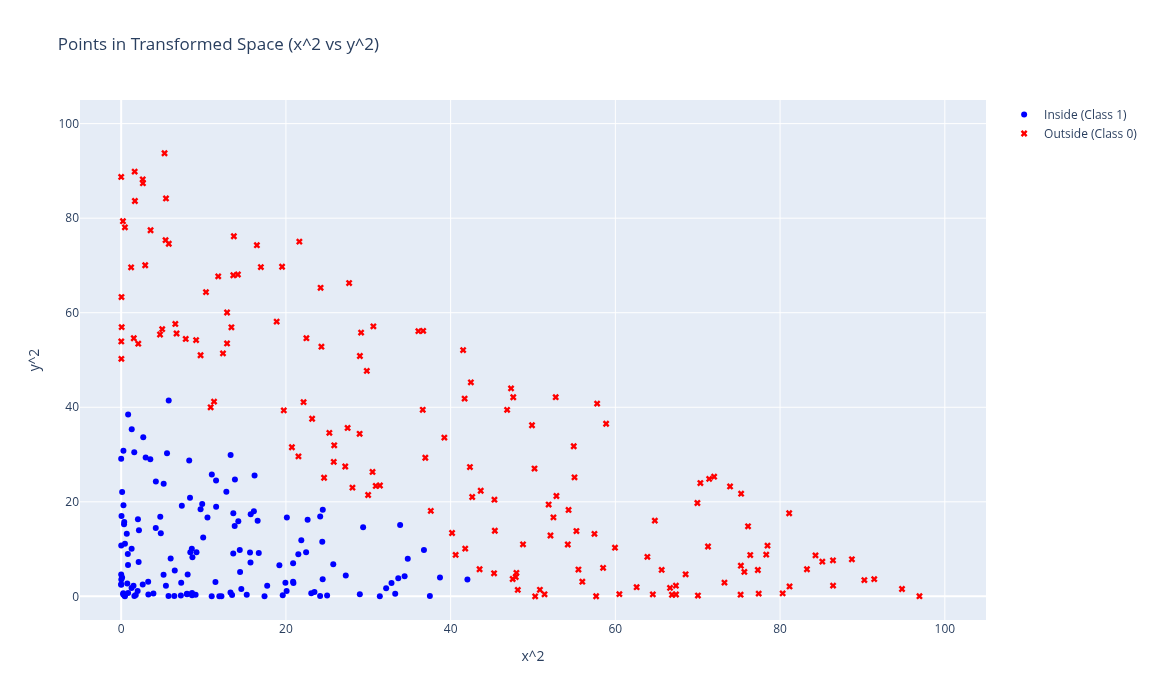

In [14]:
import numpy as np
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression

# 1. Transform features to x^2 and y^2
X_transformed = x_class**2
Y_transformed = y_class**2

# 4. Plot in the transformed space
fig_transformed = go.Figure()

# Class 1 (Inside)
fig_transformed.add_trace(go.Scatter(
    x=X_transformed[labels == 1], y=Y_transformed[labels == 1],
    mode='markers', name='Inside (Class 1)',
    marker=dict(color='blue', symbol='circle')
))

# Class 0 (Outside)
fig_transformed.add_trace(go.Scatter(
    x=X_transformed[labels == 0], y=Y_transformed[labels == 0],
    mode='markers', name='Outside (Class 0)',
    marker=dict(color='red', symbol='x')
))

fig_transformed.update_layout(
    xaxis_title='x^2',
    yaxis_title='y^2',
    width=700,
    height=700,
    title='Points in Transformed Space (x^2 vs y^2)',
    xaxis=dict(range=[-5, 105]),
    yaxis=dict(range=[-5, 105])
)

fig_transformed.show()

Well that IS linearly separable! We use Logistic Regression to come up with that decision boundary.

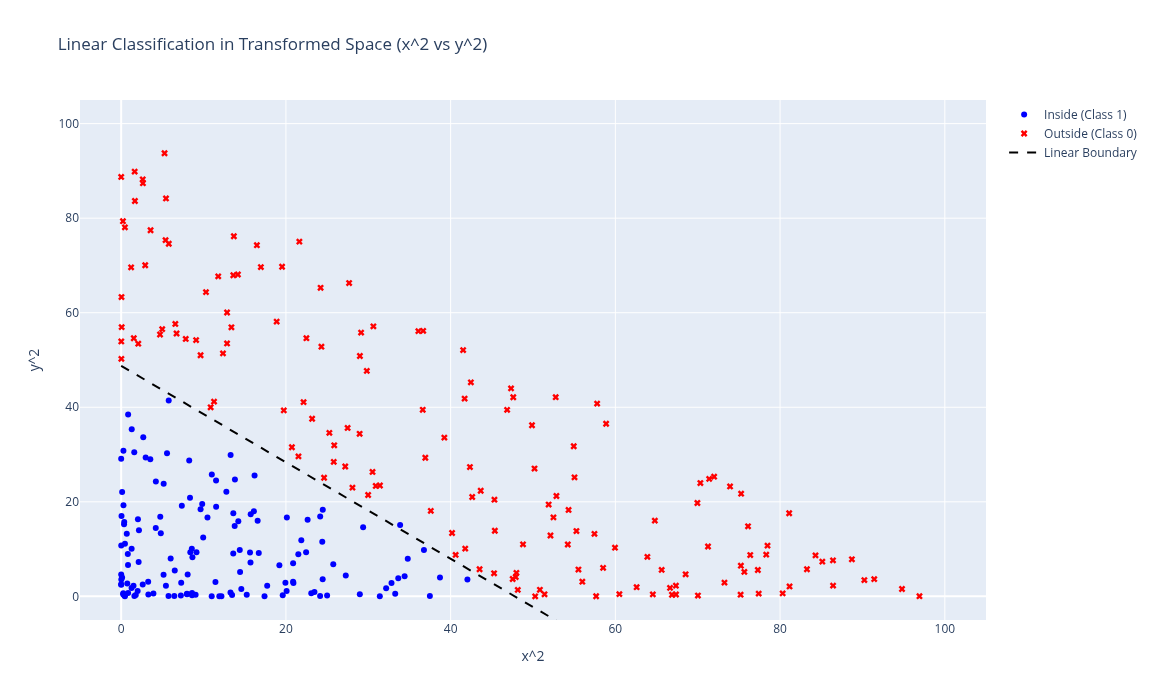

In [15]:
import numpy as np
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression

# 1. Transform features to x^2 and y^2
X_transformed = x_class**2
Y_transformed = y_class**2

# 2. Fit a linear model in the transformed space
# Features are now (x^2, y^2) instead of (x, y)
Phi_class = np.column_stack((X_transformed, Y_transformed))
clf_transformed = LogisticRegression()
clf_transformed.fit(Phi_class, labels)

# 3. Calculate the linear decision boundary in the new space
# Equation: w1*(x^2) + w2*(y^2) + b = 0
w1, w2 = clf_transformed.coef_[0]
b = clf_transformed.intercept_[0]

# Generate points for the boundary line: y^2 = -(w1/w2)x^2 - b/w2
x_sq_range = np.linspace(0, 100, 100)
y_sq_boundary = -(w1/w2) * x_sq_range - (b/w2)

# 4. Plot in the transformed space
fig_transformed = go.Figure()

# Class 1 (Inside)
fig_transformed.add_trace(go.Scatter(
    x=X_transformed[labels == 1], y=Y_transformed[labels == 1],
    mode='markers', name='Inside (Class 1)',
    marker=dict(color='blue', symbol='circle')
))

# Class 0 (Outside)
fig_transformed.add_trace(go.Scatter(
    x=X_transformed[labels == 0], y=Y_transformed[labels == 0],
    mode='markers', name='Outside (Class 0)',
    marker=dict(color='red', symbol='x')
))

# Linear Boundary
fig_transformed.add_trace(go.Scatter(
    x=x_sq_range, y=y_sq_boundary,
    mode='lines', name='Linear Boundary',
    line=dict(color='black', dash='dash')
))

fig_transformed.update_layout(
    xaxis_title='x^2',
    yaxis_title='y^2',
    width=700,
    height=700,
    title='Linear Classification in Transformed Space (x^2 vs y^2)',
    xaxis=dict(range=[-5, 105]),
    yaxis=dict(range=[-5, 105])
)

fig_transformed.show()

We then take these points and line back to the original space. The line is a weight times $x^2$, and a weight times $y^2$ - which is to say, an oval. Here's what that looks like:

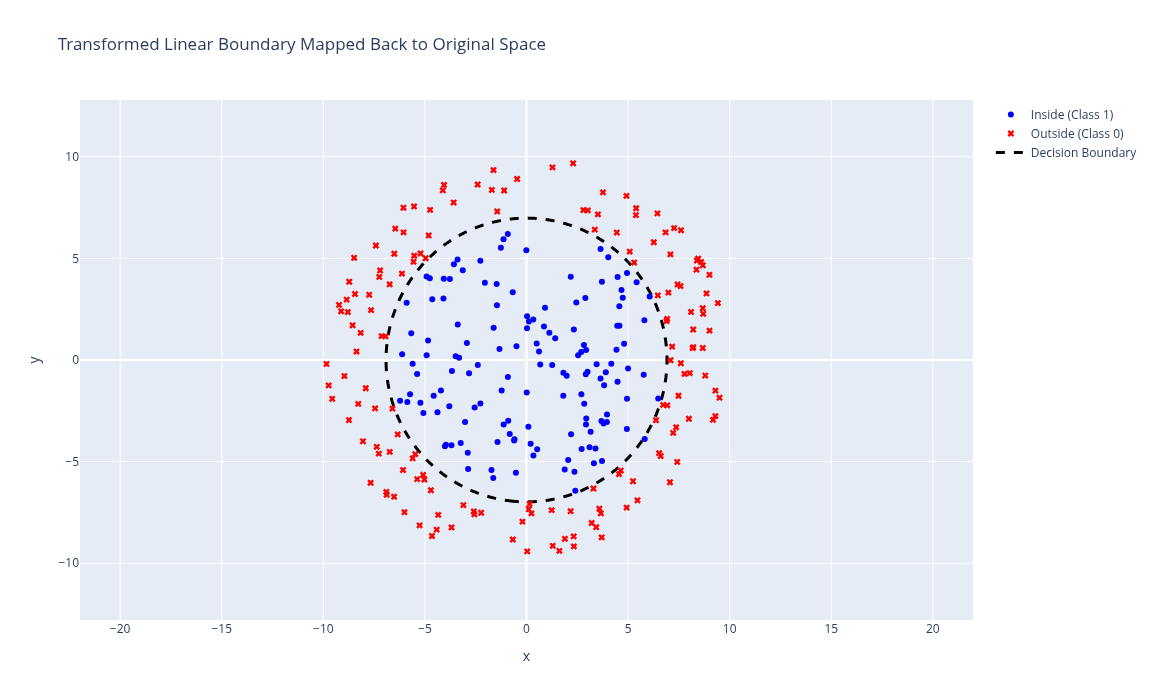

In [16]:
import numpy as np
import plotly.graph_objects as go

# 1. Create a dense grid in the original x, y space
grid_range = np.linspace(-11, 11, 300)
xx, yy = np.meshgrid(grid_range, grid_range)

# 2. Transform the grid points to match the model's features (x^2, y^2)
grid_transformed = np.c_[(xx**2).ravel(), (yy**2).ravel()]

# 3. Predict the probabilities across the grid using the transformed model
# The decision boundary exists where the probability of being in Class 1 is exactly 0.5
probs = clf_transformed.predict_proba(grid_transformed)[:, 1]
Z = probs.reshape(xx.shape)

# 4. Plot original points and the reconstructed elliptical boundary
fig_oval = go.Figure()

# Class 1 (Inside)
fig_oval.add_trace(go.Scatter(
    x=x_class[labels == 1], y=y_class[labels == 1],
    mode='markers', name='Inside (Class 1)',
    marker=dict(color='blue', symbol='circle')
))

# Class 0 (Outside)
fig_oval.add_trace(go.Scatter(
    x=x_class[labels == 0], y=y_class[labels == 0],
    mode='markers', name='Outside (Class 0)',
    marker=dict(color='red', symbol='x')
))

# Add the equivalent boundary as a contour line where probability = 0.5
fig_oval.add_trace(go.Contour(
    x=grid_range,
    y=grid_range,
    z=Z,
    showscale=False,
    contours=dict(start=0.5, end=0.5, coloring='none'),
    line=dict(color='black', width=3, dash='dash'),
    name='Decision Boundary'
))

fig_oval.update_layout(
    xaxis_title='x',
    yaxis_title='y',
    width=700,
    height=700,
    title='Transformed Linear Boundary Mapped Back to Original Space',
    xaxis=dict(range=[-11, 11], scaleanchor="y", scaleratio=1),
    yaxis=dict(range=[-11, 11])
)

fig_oval.show()

Awesome.

## Another way of thinking about this:

In this next plot we are looking at the most basic version of feature mapping.

### 1. The Dotted Line (The Basis Function)

In this plot, you will see a single diagonal dotted line. This represents your **input feature** . There's only one in this plot, $y=x$.

### 2. The Green Line (The Prediction)

The solid green line represents the **final model prediction** after training.

* You will notice that the green line is also a straight line, but it has a different slope and height (intercept) than the original dotted line.
* The green line is the model's "best guess" for fitting the noisy circular data points using only linear tools.

### 3. How the Green Line is Created

The green line is created by applying a **weight** () and an **intercept** () to that dotted line.

* The model takes the dotted line and asks: *"How much should I tilt this (weight) and how much should I shift it up or down (intercept) to get as close as possible to the blue dots?"*
* **The Math:** $\text{Green Line} = w \cdot (\text{Dotted Line}) + b$..

In this specific case, the green line is a poor fit for the data because the data is a sine wave (curved), but our building block (the dotted line) is strictly a straight line.

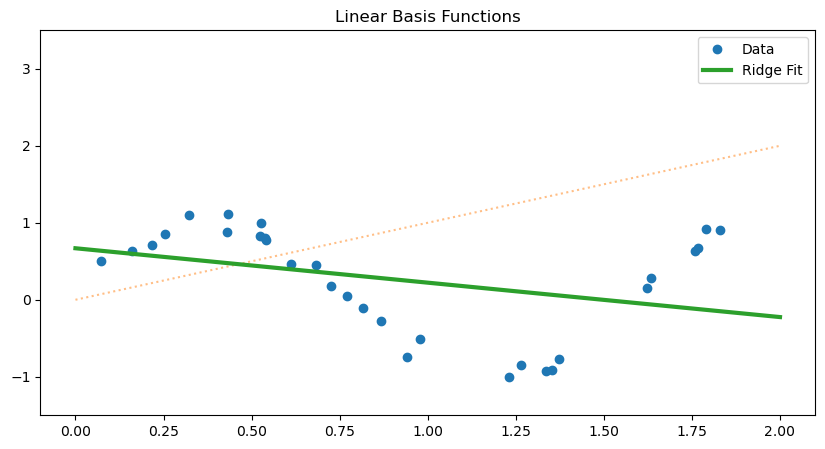

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def makeData(N, noise):
    xs = np.random.random(N) * 2
    ys = np.sin(4 * xs) + noise * np.random.randn(N)
    return xs, ys

def linearFeats(xs):
    return xs.reshape(-1, 1)

def polyFeats(xs, degree):
    Phi = np.array([[pow(x, i) for i in range(1, degree + 1)] for x in xs])
    return Phi

def RBFs(xs, centers, epsilon):
    Phi = np.array([[np.exp(-pow(epsilon * (x - xc), 2)) for xc in centers] for x in xs])
    return Phi

def plotApprox(xs, ys, testXs, Phi, testPhi, title=""):
    n, k = Phi.shape
    plt.figure(figsize=(10, 5))
    
    # Plot noisy data
    plt.plot(xs, ys, 'o', label='Data')
    
    # Plot the individual basis functions
    for i in range(k):
        plt.plot(testXs, testPhi[:, i], ':', alpha=0.5)
        
    # Replace the deprecated 'normalize=True' with a Pipeline
    model = make_pipeline(StandardScaler(), Ridge(alpha=0.01))
    model.fit(Phi, ys)
    
    testYs = model.predict(testPhi)
    
    plt.plot(testXs, testYs, linewidth=3, label='Ridge Fit')
    plt.title(title)
    plt.ylim([-1.5, 3.5])
    plt.legend()
    plt.show()

xs, ys = makeData(30, 0.1)
testXs = np.linspace(0, 2, 100)

# Linear Features
Phi = linearFeats(xs)
testPhi = linearFeats(testXs)
plotApprox(xs, ys, testXs, Phi, testPhi, title="Linear Basis Functions")

In the **"Polynomial Basis"** plot, we see what happens when we give the model more features to work with.

### 1. The Dotted Lines (The Basis Functions)

In this plot, you will see many different dotted lines. Each one represents a different power of $x$ (e.g., $x, x^2, x^3,...$).

* These are our **Polynomial Basis Functions**.
* Unlike the previous plot, which only had one straight line, we now have curves of many different shapes. Some curve upward slowly, while others spike upward very sharply.

### 2. The Green Line (The Prediction)

The solid green line is the model's final prediction. You will notice that it is no longer a straight line; it is a complex curve that follows the "snake-like" shape of the sine wave data points.

### 3. How the Green Line comes from the Dotted Lines

The green line is the **weighted sum** of all those dotted lines.

* The Linear Regression algorithm looks at all dotted lines and decides how much of each one is needed to match the data.
* It assigns a **weight** ($w$) to each dotted line. Some weights might be positive (pulling the curve up), and some might be negative (pulling the curve down).
* **The Math:** $\text{Green Line} = (w_1 \cdot x^1) + (w_2 \cdot x^2) + \dots + (w_{50} \cdot x^{50}) + b$.

By combining many simple curves (the dotted lines), the model can construct a very complex shape (the green line). Even though the final result is curved, the process is still "linear" because we are just adding up the dotted lines after scaling them by a weight.

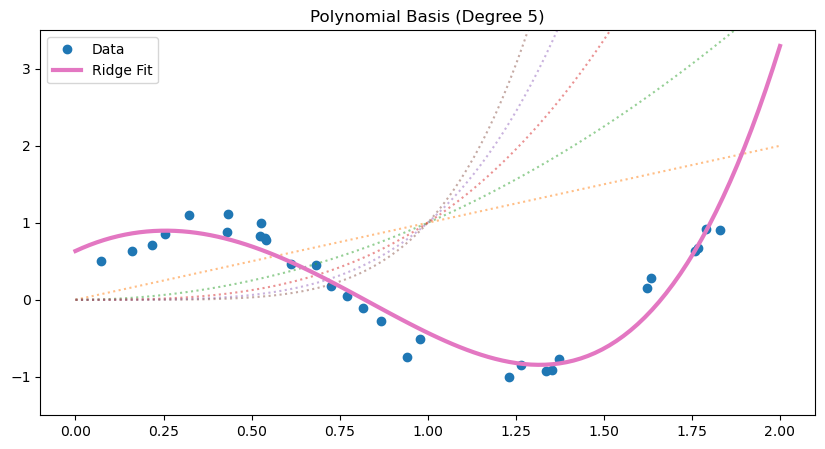

In [3]:
# Polynomial Features (Degree 5)
Phi = polyFeats(xs, 5)
testPhi = polyFeats(testXs, 5)
plotApprox(xs, ys, testXs, Phi, testPhi, title="Polynomial Basis (Degree 5)")

In the **"Radial Basis Functions (RBF)"** plot, we change our features entirely. Instead of powers of $x$, we use Gaussian curves, often called "bumps."

### 1. The Dotted Lines (The Basis Functions)

In this plot, the dotted lines are bell-shaped curves (Gaussians) centered at specific points (.5, 1, 1.5, and 2).

* Each dotted line represents a feature that only "cares" about data in its immediate neighborhood.
* For example, the bump centered at 1 is very high when $x$is near 1, but it drops to zero as you move further away.

### 2. How the Green Line comes from the Dotted Lines

The green line is constructed by **stretching or shrinking** each of these bumps and then adding them together.

* The algorithm assigns a **weight** ($w$) to each bump.
* If the sine wave is at a peak near , the model will give the bump centered at  a large positive weight. If the wave is at a trough (a valley), it will give that bump a negative weight.
* **The Math:** $\text{Green Line} = (w_1 \cdot \text{Bump}_1) + (w_2 \cdot \text{Bump}_2) + \dots + (w_5 \cdot \text{Bump}_5) + b$.

By adjusting the height and direction of these local bumps, the model can "assemble" a global curve. This is often more intuitive than polynomials because changing a weight only affects the curve near that specific bump’s center.

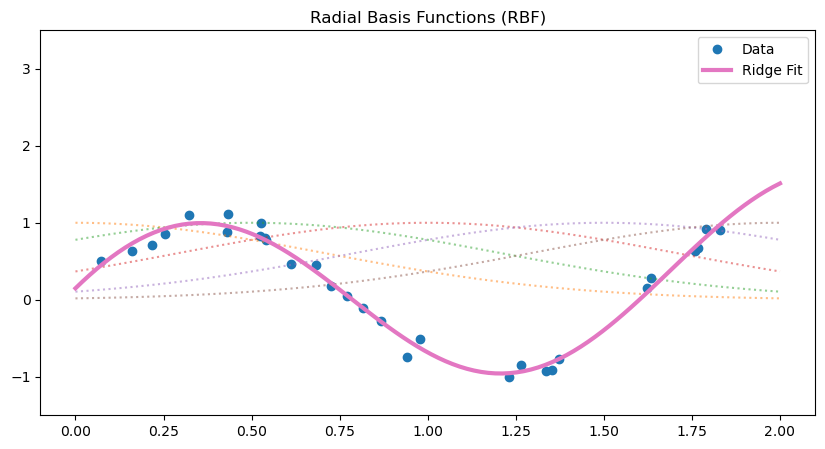

In [4]:
# Radial Basis Functions
centers = [0, .5, 1, 1.5, 2]
epsilon = 1.0
Phi = RBFs(xs, centers, epsilon)
testPhi = RBFs(testXs, centers, epsilon)
plotApprox(xs, ys, testXs, Phi, testPhi, title="Radial Basis Functions (RBF)")

## How to design features

When your linear model performs poorly, the approach to handling feature generation depends on whether the model is **overfitting** or **underfitting**.

### 1. If the Model is Overfitting

If the model is too complex and captures noise rather than the signal, you have too many features relative to your data points. To handle this:

* **Dimensionality Reduction**: Use techniques like **Principal Component Analysis (PCA)** to reduce the number of features while retaining as much variance as possible.
* **Regularization**: This isn't feature-specific, but it's a good thing to do.

### 2. If the Model is Underfitting

Underfitting occurs when the model is too simple to capture the underlying pattern. There are three primary ways to address this through feature management:

* **Consult a Domain Expert**: If the current information lacks predictive power, a domain expert can help identify what missing data or external variables are actually relevant to the target.
* **Add Linearly Independent Features**: Mathematically, underfitting often means your target vector does not lie within the **span** of your current features. To fix this, you must add new, linearly independent features to expand the space the model can explore.
* **Change the "Shape" of Features**: Sometimes the relationship is non-linear. In these cases, you generate features that allow for more flexibility. This includes:
    * **Polynomial Features**: Squaring or cubing existing variables.
    * **Splines**: Using piecewise polynomials to model complex curves.
    * **Other Basis Functions**: Transforming the input into a higher-dimensional space where a linear fit becomes possible.